In [ ]:
%pip install transformers pandas scikit-learn matplotlib seaborn

## BioBERT Fine-Tuning for Drug Review Classification

**Model**: [BioBERT v1.1](https://huggingface.co/dmis-lab/biobert-v1.1) — BERT-base-cased, continued pre-training on PubMed abstracts + PMC full-text articles.

**Approach**: Minimal text preprocessing (drug name masking only). BioBERT's WordPiece tokenizer handles subword splitting, casing, and special tokens. All layers are fine-tuned with a linear classification head on top.

> **Colab**: upload `balanced_train.csv` and `balanced_test.csv` into a `data/` folder in your workspace.

In [1]:
import copy
import re
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    get_linear_schedule_with_warmup,
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


In [4]:
DATA_DIR = "."

df_train = pd.read_csv(f"{DATA_DIR}/balanced_train.csv")
df_test = pd.read_csv(f"{DATA_DIR}/balanced_test.csv")

print(f"Training set: {len(df_train)} records, {df_train['condition'].nunique()} conditions")
print(f"Test set:     {len(df_test)} records, {df_test['condition'].nunique()} conditions")
print(f"\nTrain class distribution:")
print(df_train["condition"].value_counts())

Training set: 28614 records, 10 conditions
Test set:     22070 records, 10 conditions

Train class distribution:
condition
Depression         3432
Birth Control      3427
Pain               3416
Anxiety            3407
Acne               3107
Bipolar Disorde    2622
Insomnia           2563
Weight Loss        2389
Obesity            2240
ADHD               2011
Name: count, dtype: int64


## Preprocessing

Only drug name masking — BERT's WordPiece tokenizer handles casing, punctuation, and subword splitting internally. No stop-word removal or lemmatization needed.

In [5]:
DRUG_PLACEHOLDER = "medication"


def mask_drug_name(text: str, drug_name: str) -> str:
    if pd.isna(drug_name) or pd.isna(text):
        return text if not pd.isna(text) else ""
    pattern = re.compile(re.escape(drug_name), re.IGNORECASE)
    return pattern.sub(DRUG_PLACEHOLDER, text)


df_train["review_masked"] = df_train.apply(
    lambda row: mask_drug_name(row["review"], row["drugName"]),
    axis=1,
)
df_test["review_masked"] = df_test.apply(
    lambda row: mask_drug_name(row["review"], row["drugName"]),
    axis=1,
)

print("Original:", df_train.iloc[0]["review"][:200])
print()
print("Masked:  ", df_train.iloc[0]["review_masked"][:200])

Original: "This drug does well for the purpose it was prescribed for: reduction of anxiety. However I commonly suffer from sleep walking, sleep motions and even talking. This drug really kicked all of that into

Masked:   "This drug does well for the purpose it was prescribed for: reduction of anxiety. However I commonly suffer from sleep walking, sleep motions and even talking. This drug really kicked all of that into


In [6]:
MODEL_NAME = "dmis-lab/biobert-v1.1"

MAX_SEQ_LEN = 256
BATCH_SIZE = 16
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
NUM_EPOCHS = 4
WARMUP_RATIO = 0.1
VAL_RATIO = 0.15
GRAD_CLIP_NORM = 1.0
ES_PATIENCE = 2

## Tokenization & Data Preparation

BioBERT's WordPiece tokenizer converts raw text into `input_ids` + `attention_mask`. Sequences are truncated/padded to `MAX_SEQ_LEN` tokens.

In [7]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

labels_sorted = sorted(df_train["condition"].unique())
label2id = {label: idx for idx, label in enumerate(labels_sorted)}
id2label = {idx: label for label, idx in label2id.items()}
NUM_CLASSES = len(labels_sorted)
print(f"Classes ({NUM_CLASSES}): {labels_sorted}")

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df_train["review_masked"].tolist(),
    df_train["condition"].map(label2id).tolist(),
    test_size=VAL_RATIO,
    random_state=42,
    stratify=df_train["condition"],
)
test_texts = df_test["review_masked"].tolist()
test_labels = df_test["condition"].map(label2id).tolist()

print(f"Train: {len(train_texts)}, Val: {len(val_texts)}, Test: {len(test_texts)}")


class ReviewDataset(Dataset):
    def __init__(
        self,
        texts: list[str],
        labels: list[int],
        tokenizer,
        max_len: int,
    ) -> None:
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding="max_length",
            max_length=max_len,
            return_tensors="pt",
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int) -> dict[str, torch.Tensor]:
        return {
            "input_ids": self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels": self.labels[idx],
        }


train_dataset = ReviewDataset(train_texts, train_labels, tokenizer, MAX_SEQ_LEN)
val_dataset = ReviewDataset(val_texts, val_labels, tokenizer, MAX_SEQ_LEN)
test_dataset = ReviewDataset(test_texts, test_labels, tokenizer, MAX_SEQ_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE * 2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE * 2)

print(
    f"\nBatches per epoch — "
    f"Train: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/462 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Classes (10): ['ADHD', 'Acne', 'Anxiety', 'Bipolar Disorde', 'Birth Control', 'Depression', 'Insomnia', 'Obesity', 'Pain', 'Weight Loss']
Train: 24321, Val: 4293, Test: 22070

Batches per epoch — Train: 1521, Val: 135, Test: 690


In [8]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    id2label=id2label,
    label2id=label2id,
)
model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

pytorch_model.bin:   0%|          | 0.00/433M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-v1.1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters:     108,317,962
Trainable parameters: 108,317,962


## Training

AdamW with differential weight decay (none for bias and LayerNorm). Linear LR warmup for the first 10% of steps, then linear decay to zero. Early stopping on validation loss.

In [9]:
no_decay = ("bias", "LayerNorm.weight")
optimizer_grouped_parameters = [
    {
        "params": [
            p for n, p in model.named_parameters()
            if not any(nd in n for nd in no_decay)
        ],
        "weight_decay": WEIGHT_DECAY,
    },
    {
        "params": [
            p for n, p in model.named_parameters()
            if any(nd in n for nd in no_decay)
        ],
        "weight_decay": 0.0,
    },
]

optimizer = torch.optim.AdamW(optimizer_grouped_parameters, lr=LEARNING_RATE)

total_steps = len(train_loader) * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f"Total steps: {total_steps}, Warmup steps: {warmup_steps}")

best_val_loss = float("inf")
best_model_state = None
patience_counter = 0

history: dict[str, list[float]] = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
}

for epoch in range(NUM_EPOCHS):
    t0 = time.time()

    # ---- Train ----
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{NUM_EPOCHS} [Train]")
    for batch in pbar:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = model(**batch)

        outputs.loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        bs = batch["labels"].size(0)
        running_loss += outputs.loss.item() * bs
        preds = outputs.logits.argmax(dim=-1)
        correct += (preds == batch["labels"]).sum().item()
        total += bs

        pbar.set_postfix(
            loss=f"{running_loss / total:.4f}",
            acc=f"{correct / total:.4f}",
        )

    train_loss = running_loss / total
    train_acc = correct / total

    # ---- Validate ----
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch + 1}/{NUM_EPOCHS} [Val]"):
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)

            bs = batch["labels"].size(0)
            running_loss += outputs.loss.item() * bs
            preds = outputs.logits.argmax(dim=-1)
            correct += (preds == batch["labels"]).sum().item()
            total += bs

    val_loss = running_loss / total
    val_acc = correct / total

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    elapsed = time.time() - t0
    print(
        f"Epoch {epoch + 1}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f} | "
        f"{elapsed:.0f}s"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
        print(f"  -> New best model (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= ES_PATIENCE:
            print(f"  Early stopping at epoch {epoch + 1}")
            break

model.load_state_dict(best_model_state)
print(f"\nLoaded best model (val_loss={best_val_loss:.4f})")

Total steps: 6084, Warmup steps: 608


Epoch 1/4 [Train]:   0%|          | 0/1521 [00:00<?, ?it/s]

Epoch 1/4 [Val]:   0%|          | 0/135 [00:00<?, ?it/s]

Epoch 1/4 | Train Loss: 0.9553  Acc: 0.6669 | Val Loss: 0.5739  Acc: 0.7843 | 1235s
  -> New best model (val_loss=0.5739)


Epoch 2/4 [Train]:   0%|          | 0/1521 [00:00<?, ?it/s]

...

Epoch 3/4 [Val]:   0%|          | 0/135 [00:00<?, ?it/s]

Epoch 3/4 | Train Loss: 0.3534  Acc: 0.8649 | Val Loss: 0.5594  Acc: 0.8053 | 1238s


Epoch 4/4 [Train]:   0%|          | 0/1521 [00:00<?, ?it/s]

Epoch 4/4 [Val]:   0%|          | 0/135 [00:00<?, ?it/s]

Epoch 4/4 | Train Loss: 0.2674  Acc: 0.8989 | Val Loss: 0.5951  Acc: 0.8081 | 1238s
  Early stopping at epoch 4

Loaded best model (val_loss=0.5272)


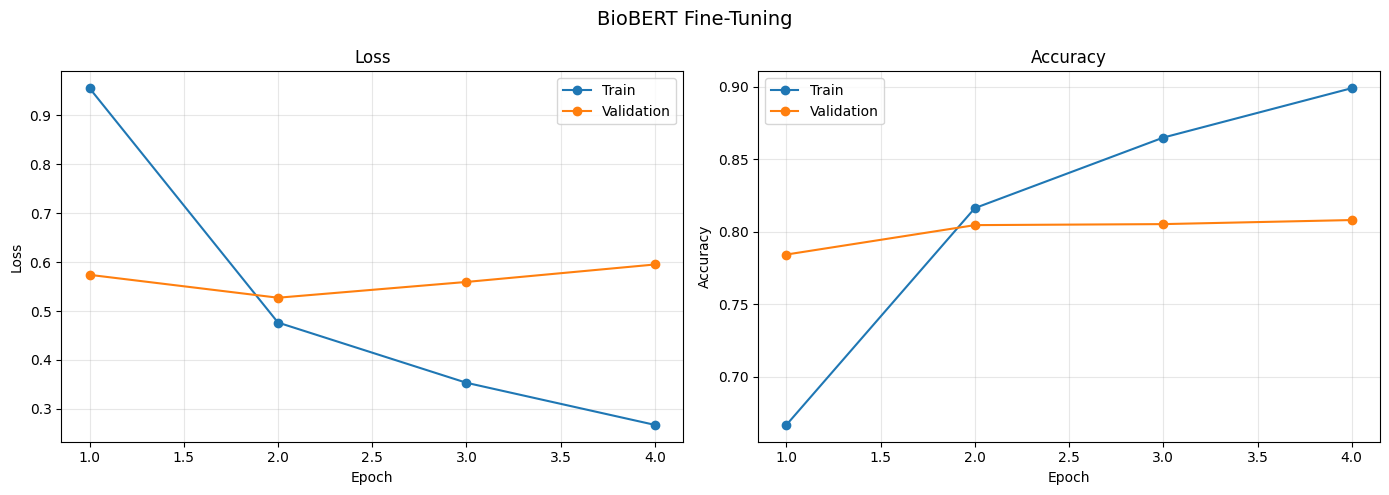

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs_range, history["train_loss"], "o-", label="Train")
axes[0].plot(epochs_range, history["val_loss"], "o-", label="Validation")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history["train_acc"], "o-", label="Train")
axes[1].plot(epochs_range, history["val_acc"], "o-", label="Validation")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle("BioBERT Fine-Tuning", fontsize=14)
plt.tight_layout()
plt.show()

## Evaluation on Test Set

In [11]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = model(**batch)
        preds = outputs.logits.argmax(dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch["labels"].cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {test_acc:.4f}\n")
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=labels_sorted,
        digits=4,
    )
)

Testing:   0%|          | 0/690 [00:00<?, ?it/s]

Test Accuracy: 0.8581

                 precision    recall  f1-score   support

           ADHD     0.9164    0.8724    0.8939       980
           Acne     0.9030    0.9291    0.9159      1693
        Anxiety     0.6885    0.8226    0.7496      1747
Bipolar Disorde     0.7751    0.7694    0.7722      1236
  Birth Control     0.9875    0.9529    0.9699      8402
     Depression     0.7581    0.7280    0.7428      2798
       Insomnia     0.8661    0.8722    0.8691      1127
        Obesity     0.5679    0.5873    0.5774      1054
           Pain     0.9110    0.9451    0.9278      1896
    Weight Loss     0.6265    0.6033    0.6147      1137

       accuracy                         0.8581     22070
      macro avg     0.8000    0.8082    0.8033     22070
   weighted avg     0.8618    0.8581    0.8593     22070



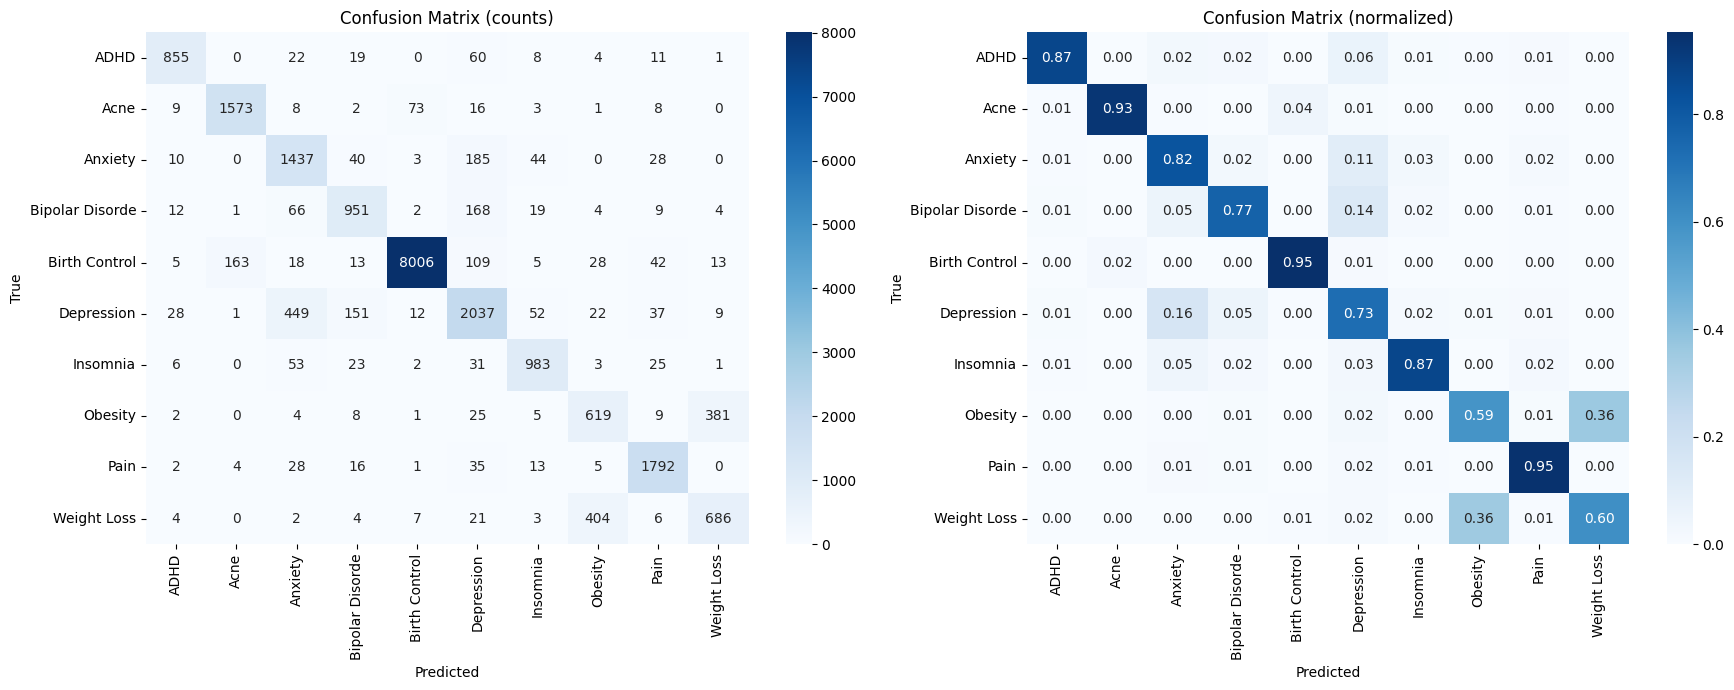

In [12]:
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels_sorted,
    yticklabels=labels_sorted,
    ax=axes[0],
)
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].set_title("Confusion Matrix (counts)")

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels_sorted,
    yticklabels=labels_sorted,
    ax=axes[1],
)
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
axes[1].set_title("Confusion Matrix (normalized)")

plt.tight_layout()
plt.show()